In [1]:
import sys
sys.path.append('..')

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from config import small_dataset_path

In [3]:
with h5py.File(small_dataset_path, 'r') as f:
    waveforms = f['waveforms'][:]
waveforms.shape

(200000, 4, 128)

In [9]:
idxs = [183_289, 49]
selected_waveforms = waveforms[idxs]
selected_waveforms.shape

first_waveform = selected_waveforms[0]
second_waveform = selected_waveforms[1]

first_waveform_A_real = first_waveform[0]
first_waveform_A_imag = first_waveform[1]
first_waveform_E_real = first_waveform[2]
first_waveform_E_imag = first_waveform[3]

second_waveform_A_real = second_waveform[0]
second_waveform_A_imag = second_waveform[1]
second_waveform_E_real = second_waveform[2]
second_waveform_E_imag = second_waveform[3]

In [10]:
rng = np.random.default_rng(42)

def apply_random_scaling(summed_waveforms):
    scale_min = 0.5
    scale_max = 2.0
    log_scale = rng.uniform(
        np.log(scale_min),
        np.log(scale_max),
    )
    scale = np.exp(log_scale)
    summed_waveforms = summed_waveforms * scale
    return summed_waveforms

def add_random_noise(summed_waveforms):
    noise = rng.normal(0, 1, size=summed_waveforms.shape)
    summed_waveforms = summed_waveforms + noise
    return summed_waveforms

In [20]:
from scipy.interpolate import make_interp_spline

def plot_signal(signal, color='green', smooth_sigma=1.5):
    y = np.asarray(signal).ravel()
    x = np.arange(len(y))

    if smooth_sigma > 0:
        y = gaussian_filter1d(y, sigma=smooth_sigma)

    x_smooth = np.linspace(x.min(), x.max(), len(x) * 8)
    y_smooth = make_interp_spline(x, y, k=3)(x_smooth)

    _, ax = plt.subplots(figsize=(12, 3))
    ax.set_axisbelow(True)

    ax.plot(
        x_smooth,
        y_smooth,
        color=color,
        linewidth=2.5,
        alpha=0.95,
        solid_capstyle='round',
        solid_joinstyle='round',
    )

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()


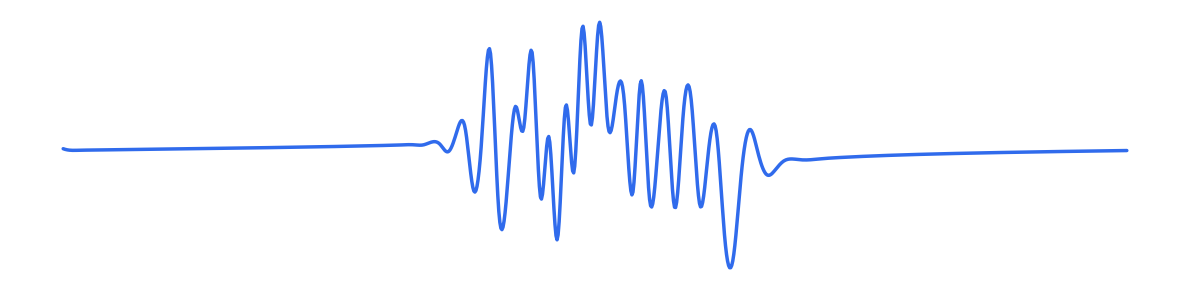

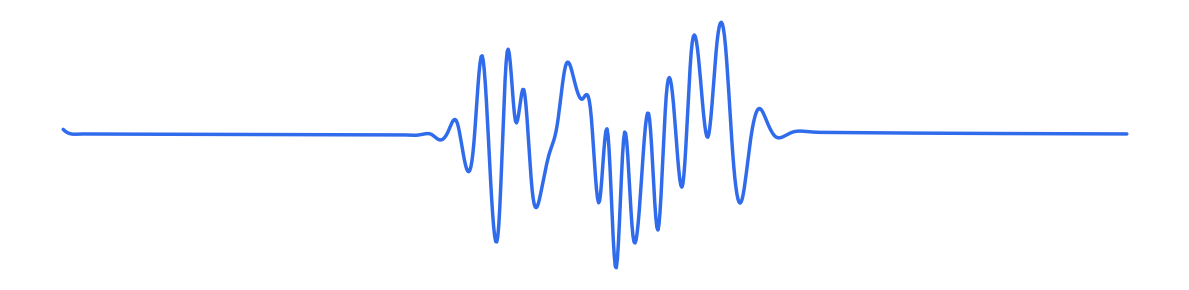

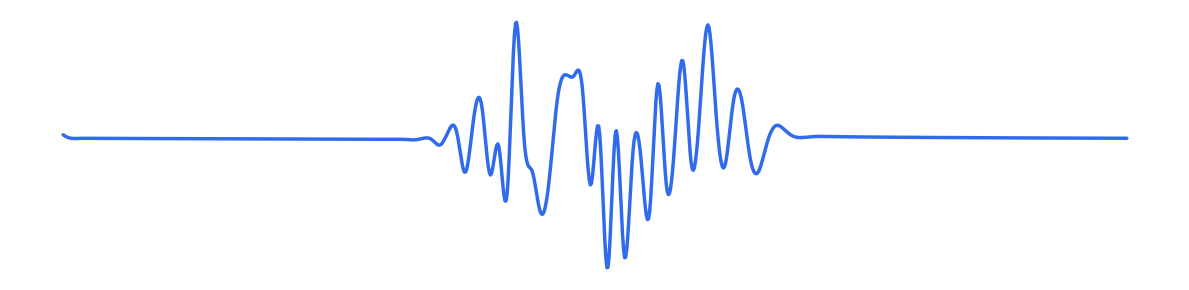

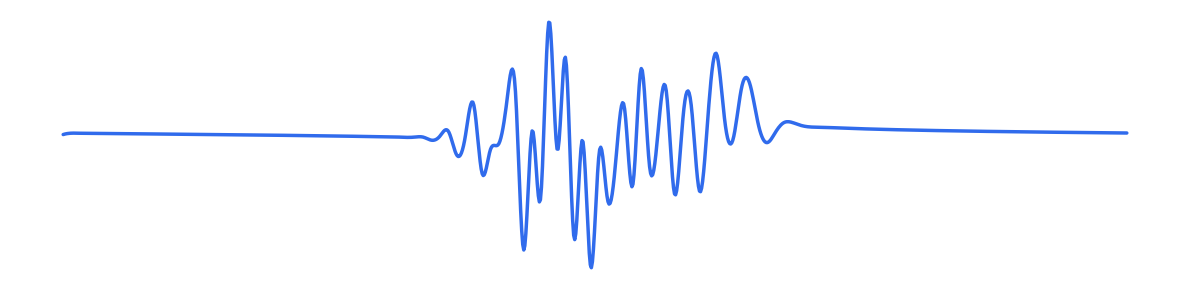

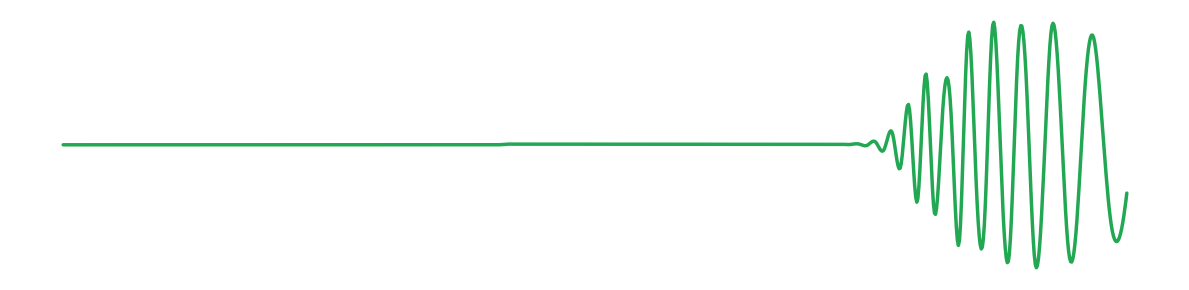

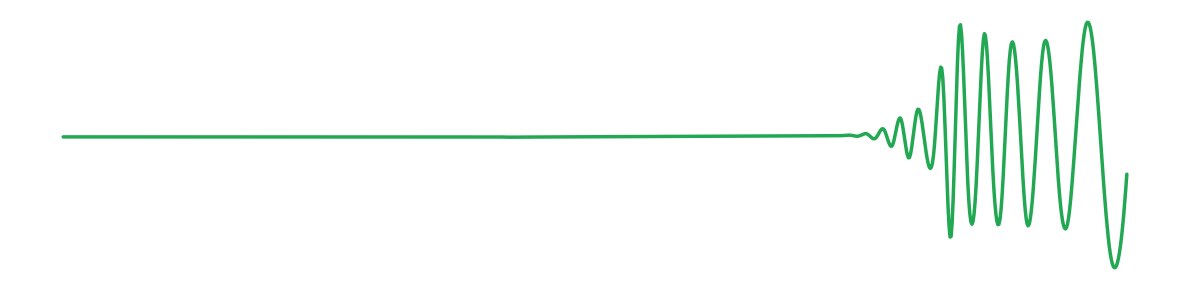

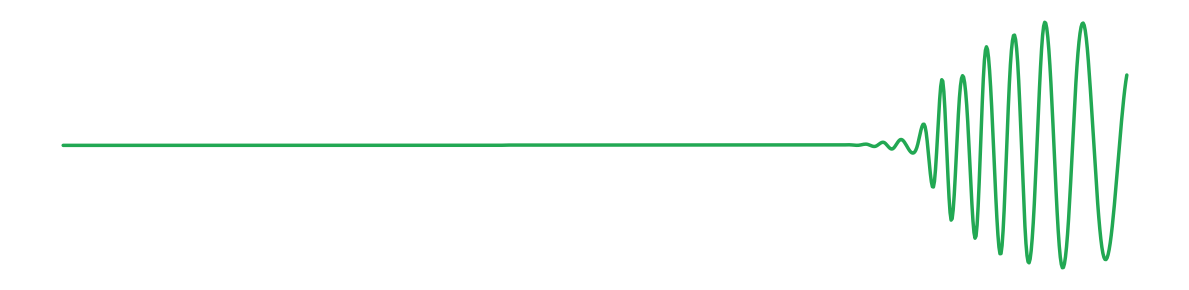

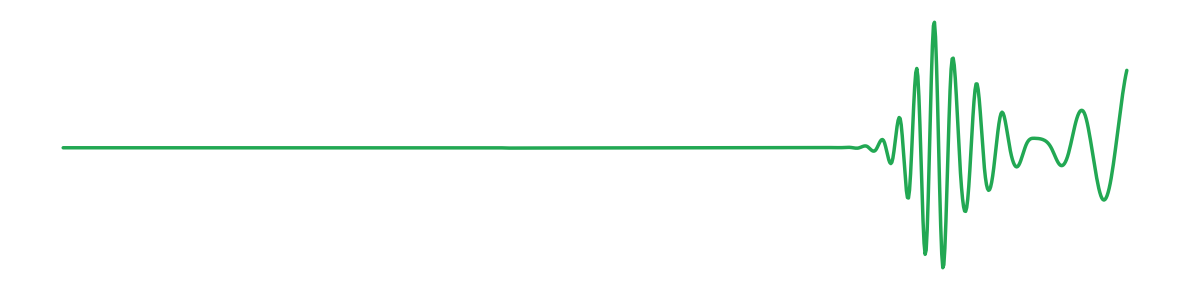

In [21]:
for i in range(len(selected_waveforms)):
    waveform = selected_waveforms[i]
    color = "#2563eb" if i == 0 else "#16a34a"
    for j in range(waveform.shape[0]):
        signal = waveform[j]
        plot_signal(signal, color=color, smooth_sigma=0.0)

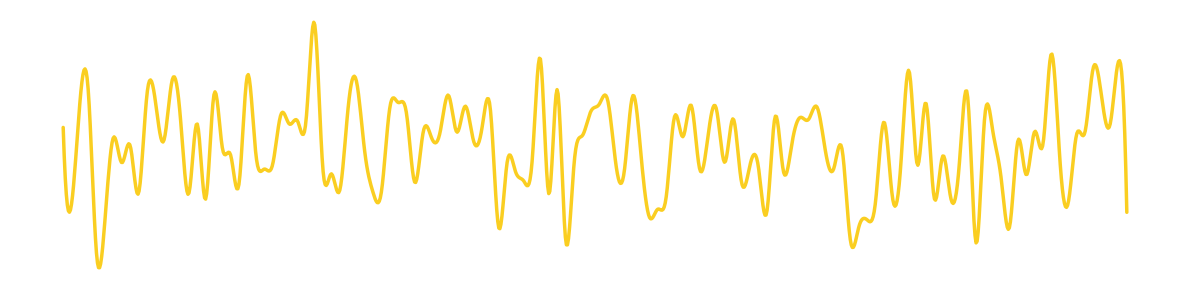

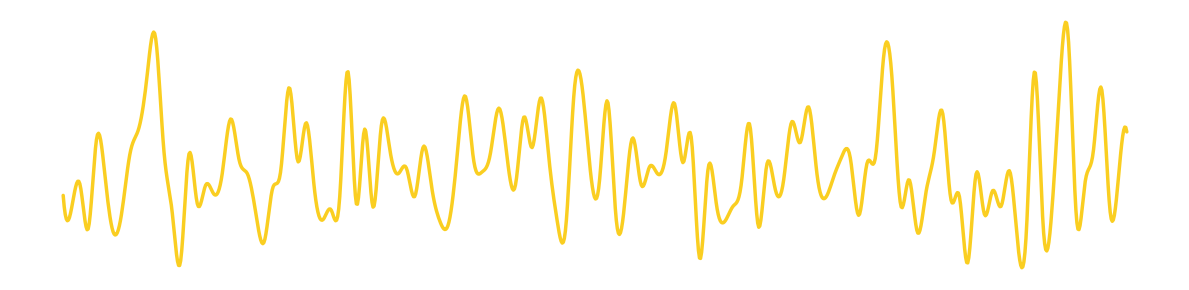

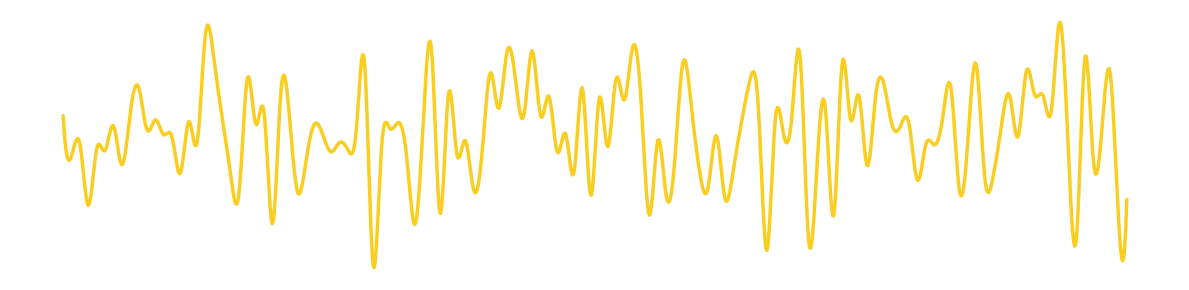

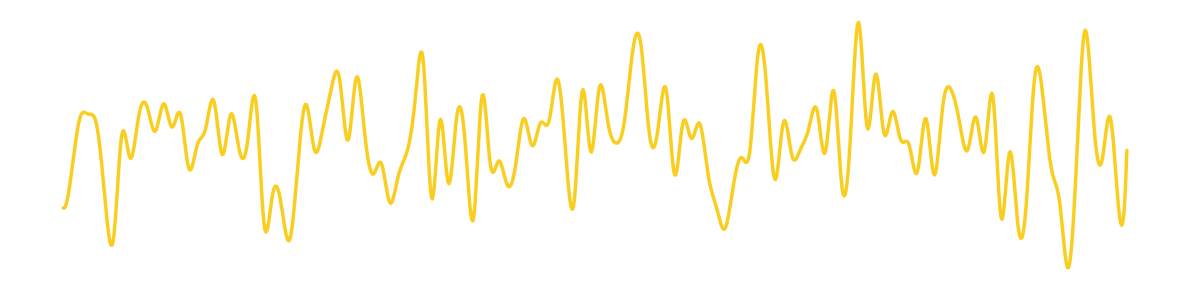

In [22]:
gaussian_noise = rng.normal(0, 1, size=first_waveform.shape)
for j in range(gaussian_noise.shape[0]):
    signal = gaussian_noise[j]
    plot_signal(signal, color="#facc15", smooth_sigma=0.0)

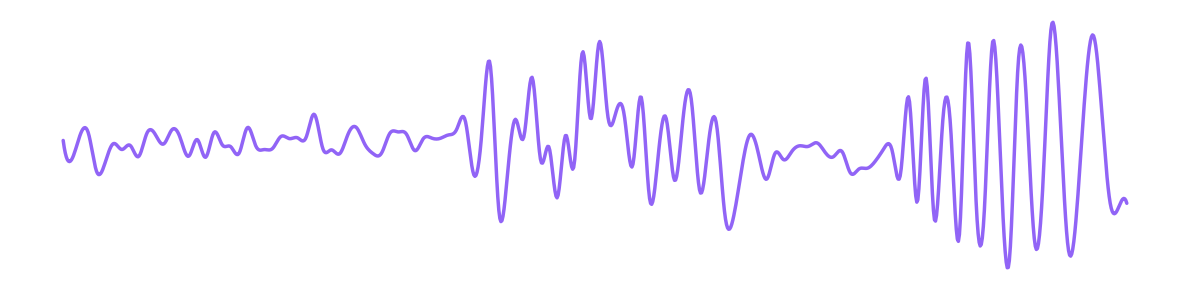

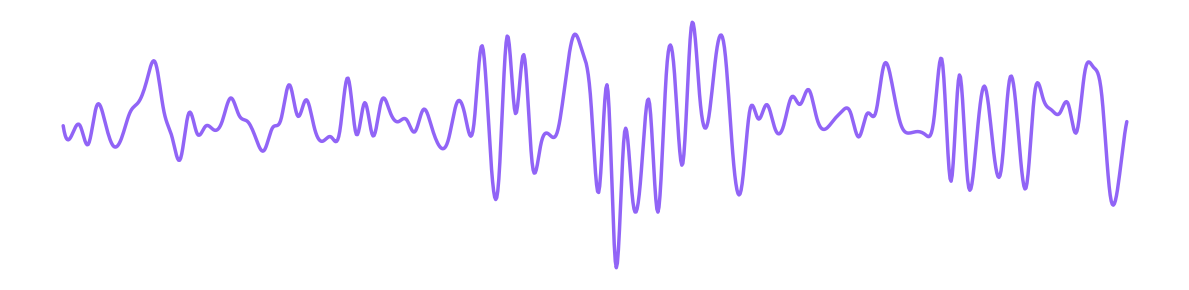

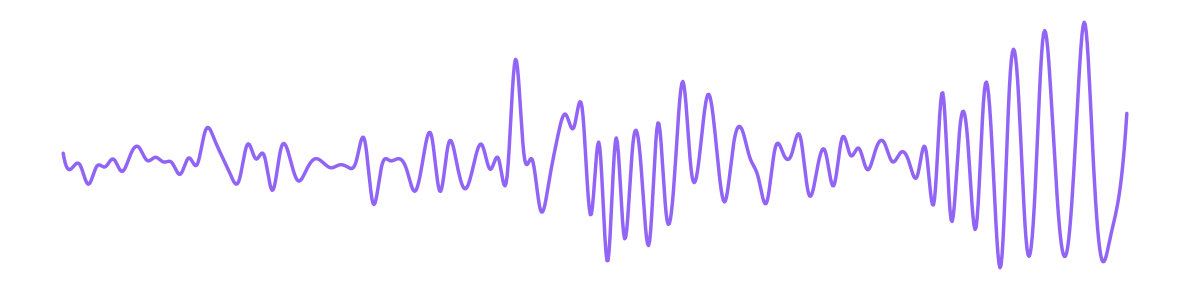

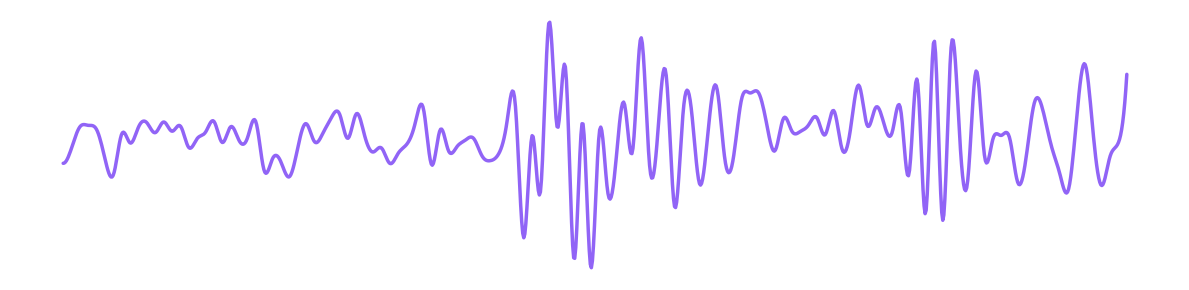

In [24]:
summed_waveforms = first_waveform + second_waveform + gaussian_noise
for j in range(summed_waveforms.shape[0]):
    signal = summed_waveforms[j]
    plot_signal(signal, color="#8b5cf6", smooth_sigma=0.0)

In [27]:
S_bar = summed_waveforms / 2
S_bar.shape

(4, 128)